In [ ]:
# ===== Import các thư viện cần thiết =====
import os  # Quản lý file, thư mục
import cv2  # Xử lý ảnh
import numpy as np  # Tính toán ma trận, mảng
import matplotlib.pyplot as plt  # Vẽ biểu đồ, hiển thị ảnh

from collections import Counter  # Đếm số lượng phần tử trong danh sách, dùng để thống kê nhãn

# ===== Import TensorFlow / Keras để xây dựng mô hình học sâu =====
import tensorflow as tf
from tensorflow.keras import layers, models  # layers: các lớp mạng; models: tạo model Keras

# ===== Import các công cụ đánh giá mô hình =====
from sklearn.metrics import (
    accuracy_score,      # Tính độ chính xác
    precision_score,     # Tính độ chính xác theo class (precision)
    recall_score,        # Tính độ hồi tưởng (recall)
    f1_score,            # Tính F1-score
    classification_report,  # Báo cáo chi tiết về precision, recall, F1-score
    confusion_matrix,       # Ma trận nhầm lẫn
    ConfusionMatrixDisplay  # Hiển thị ma trận nhầm lẫn đẹp
)


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [ ]:


# ====== ĐƯỜNG DẪN ======
train_dir = r"D:\My saved documents\code\Chilies detection\train"
valid_dir = r"D:\My saved documents\code\Chilies detection\valid"

valid_exts = (".jpg", ".jpeg", ".png", ".bmp")

# ====== HÀM QUÉT ẢNH ======
def collect_image_sizes(root_dir):
    sizes = []
    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        for fname in os.listdir(class_path):
            if fname.lower().endswith(valid_exts):
                img_path = os.path.join(class_path, fname)
                img = cv2.imread(img_path)
                if img is None:
                    continue
                h, w = img.shape[:2]
                sizes.append((w, h))
    return sizes


# ====== THU THẬP ======
train_sizes = collect_image_sizes(train_dir)
valid_sizes = collect_image_sizes(valid_dir)

print(f"Train images: {len(train_sizes)}")
print(f"Valid images: {len(valid_sizes)}")

# ====== ĐẾM KÍCH THƯỚC ======
train_counter = Counter(train_sizes)
valid_counter = Counter(valid_sizes)

# ====== IN RA TOP KÍCH THƯỚC ======
print("\nTop image sizes in TRAIN:")
for size, count in train_counter.most_common(10):
    print(f"{size}: {count}")

print("\nTop image sizes in VALID:")
for size, count in valid_counter.most_common(10):
    print(f"{size}: {count}")




Train images: 590
Valid images: 104

Top image sizes in TRAIN:
(224, 224): 590

Top image sizes in VALID:
(224, 224): 104


TRAIN class distribution:
Defective_chili: 116
Dry_chili: 265
Normal_chili: 209

VALID class distribution:
Defective_chili: 35
Dry_chili: 36
Normal_chili: 33


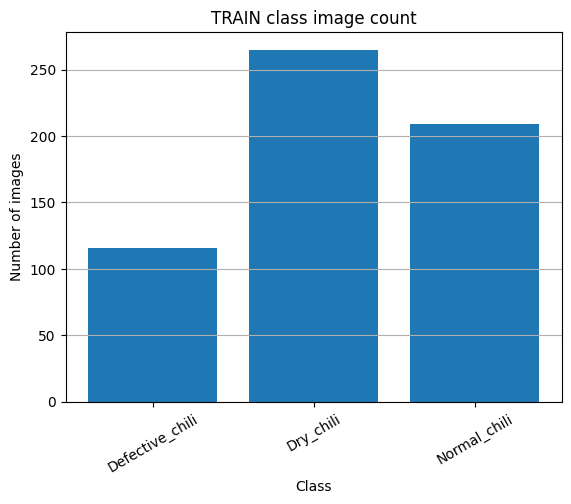

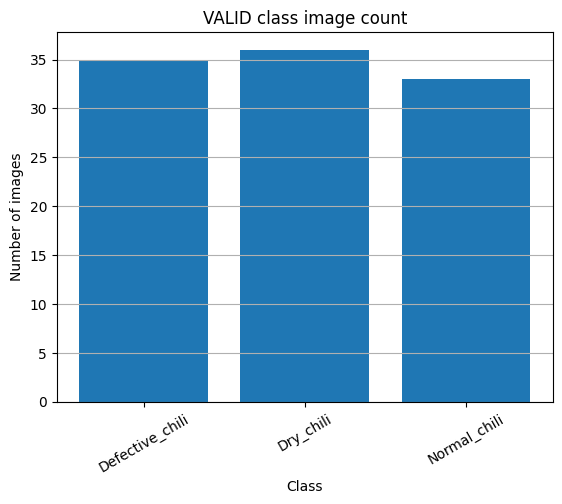

In [ ]:



# ====== HÀM ĐẾM ẢNH THEO CLASS ======
def count_images_per_class(root_dir):
    class_names = []
    counts = []

    for class_name in os.listdir(root_dir):
        class_path = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        num_images = sum(
            fname.lower().endswith(valid_exts)
            for fname in os.listdir(class_path)
        )

        class_names.append(class_name)
        counts.append(num_images)

    return class_names, counts
def plot_class_distribution(class_names, counts, title):
    plt.figure()
    plt.bar(class_names, counts)
    plt.xlabel("Class")
    plt.ylabel("Number of images")
    plt.title(title)
    plt.xticks(rotation=30)
    plt.grid(axis="y")
    plt.show()
train_classes, train_counts = count_images_per_class(train_dir)
valid_classes, valid_counts = count_images_per_class(valid_dir)

print("TRAIN class distribution:")
for c, n in zip(train_classes, train_counts):
    print(f"{c}: {n}")

print("\nVALID class distribution:")
for c, n in zip(valid_classes, valid_counts):
    print(f"{c}: {n}")

plot_class_distribution(train_classes, train_counts, "TRAIN class image count")
plot_class_distribution(valid_classes, valid_counts, "VALID class image count")


In [ ]:
# ================== CẤU HÌNH ==================

# Thư mục chứa ảnh huấn luyện
TRAIN_DIR = r"D:\My saved documents\code\Chilies detection\train"

# Thư mục chứa ảnh validation (dùng để đánh giá model trong quá trình huấn luyện)
VALID_DIR = r"D:\My saved documents\code\Chilies detection\valid"

# Kích thước ảnh đưa vào mạng (chiều cao x chiều rộng)
# Hầu hết các mô hình CNN pre-trained như ResNet, MobileNet yêu cầu 224x224
IMG_SIZE = (224, 224)

# Số ảnh xử lý cùng lúc trong một batch
BATCH_SIZE = 16

# Số epoch (vòng lặp qua toàn bộ dữ liệu huấn luyện)
EPOCHS = 20

# Hạt giống (seed) dùng để đảm bảo kết quả tái lập lại được
SEED = 42


In [ ]:
# ================== LOAD TRAIN ==================
# Tạo dataset huấn luyện từ thư mục ảnh
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,            # Thư mục chứa ảnh huấn luyện
    image_size=IMG_SIZE,  # Resize ảnh về kích thước IMG_SIZE (224x224)
    batch_size=BATCH_SIZE,# Số ảnh trong một batch
    shuffle=True,         # Trộn ngẫu nhiên ảnh trong mỗi epoch
    seed=SEED             # Seed để đảm bảo kết quả shuffle có thể tái lập lại
)

# Lấy danh sách tên class (dựa vào tên thư mục con trong TRAIN_DIR)
class_names = train_ds.class_names

# ================== LOAD VALID ==================
# Tạo dataset validation từ thư mục ảnh
val_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,            # Thư mục chứa ảnh validation
    image_size=IMG_SIZE,  # Resize ảnh về kích thước IMG_SIZE
    batch_size=BATCH_SIZE,# Số ảnh trong một batch
    shuffle=False         # Không trộn dữ liệu validation
)

# Lấy số lượng class
num_classes = len(class_names)

# In thông tin ra màn hình
print("Classes:", class_names)
print("Number of classes:", num_classes)


Found 590 files belonging to 3 classes.
Found 104 files belonging to 3 classes.
Classes: ['Defective_chili', 'Dry_chili', 'Normal_chili']
Number of classes: 3


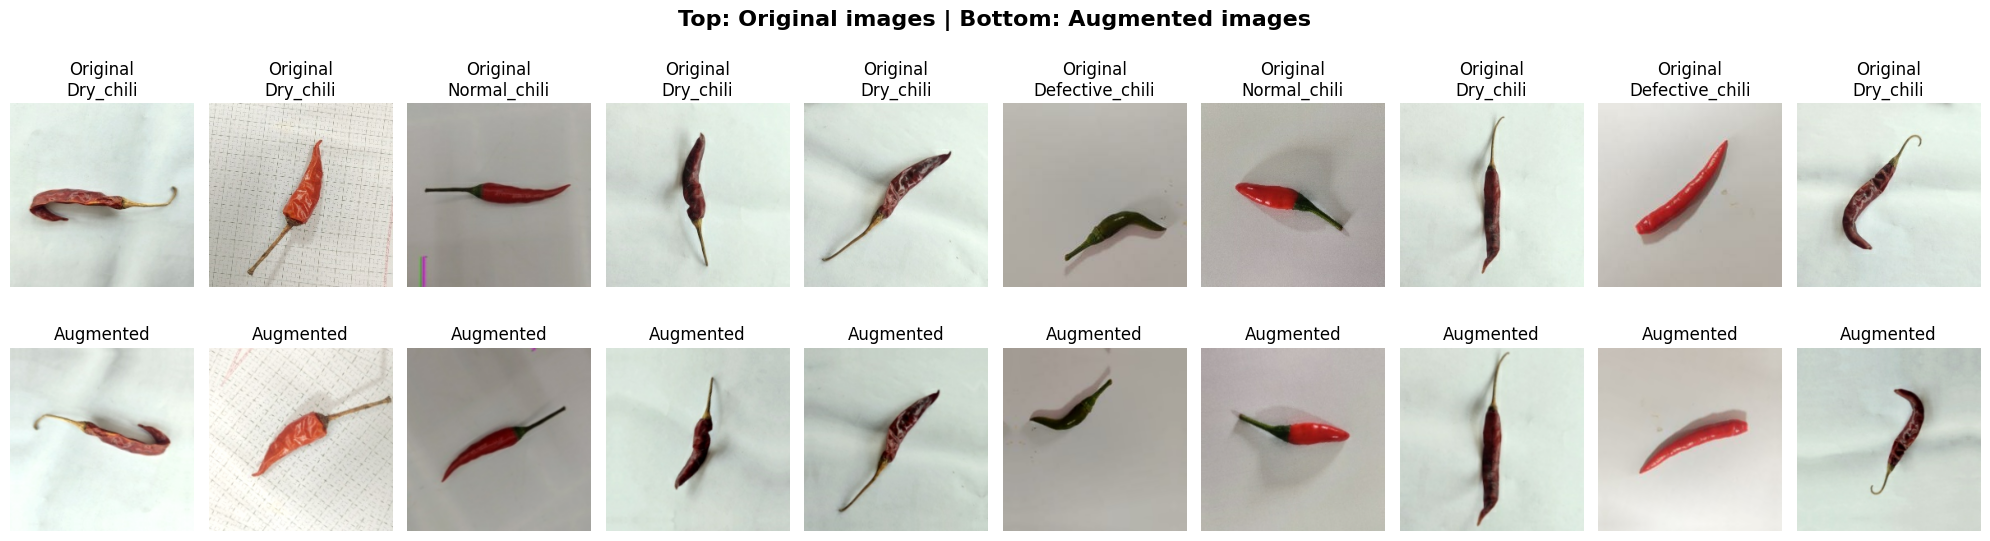

In [ ]:
# ================== DATA AUGMENTATION ==================
# Tạo pipeline augment ảnh bằng Keras Sequential
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),  # Lật ảnh ngang + dọc ngẫu nhiên
    tf.keras.layers.RandomRotation(0.1),                   # Xoay ảnh ±10% (khoảng ±36 độ)
    tf.keras.layers.RandomZoom(0.2),                       # Zoom in/out ±20%
    tf.keras.layers.RandomContrast(0.1),                   # Thay đổi độ tương phản ±10%
    tf.keras.layers.RandomBrightness(0.1),                 # Thay đổi độ sáng ±10%
    tf.keras.layers.GaussianNoise(0.01),                   # Thêm nhiễu Gaussian (0.01)
])

# ================== TẠO 4 ẢNH TỪ 1 ẢNH: 1 GỐC + 3 AUGMENT ==================
def create_four_images_from_one(image, label, num_augmentations=3):
    """
    Từ một ảnh, tạo ra 4 ảnh: 1 ảnh gốc + 3 ảnh augment
    Trả về một tf.data.Dataset
    """
    images_list = []
    labels_list = []
    
    # 1. Thêm ảnh gốc
    images_list.append(image)
    labels_list.append(label)
    
    # 2. Tạo ảnh augment
    for _ in range(num_augmentations):
        # data_augmentation yêu cầu input batch, nên thêm dimension
        aug_img = data_augmentation(tf.expand_dims(image, 0), training=True)
        images_list.append(aug_img[0])  # Lấy ảnh đầu tiên trong batch
        labels_list.append(label)       # Nhãn giữ nguyên
    
    # 3. Chuyển danh sách ảnh + nhãn thành dataset
    return tf.data.Dataset.from_tensor_slices((images_list, labels_list))


import matplotlib.pyplot as plt
import tensorflow as tf

def show_before_after_augmentation(train_ds, class_names, num_images=10):
    # Lấy 10 ảnh gốc đầu tiên
    images, labels = next(iter(train_ds.unbatch().batch(num_images)))

    plt.figure(figsize=(20, 6))

    for i in range(num_images):
        img = images[i]
        label = labels[i]

        # ===== ẢNH TRƯỚC LÀM GIÀU =====
        plt.subplot(2, num_images, i + 1)
        plt.imshow(tf.cast(img, tf.uint8))
        plt.title(f"Original\n{class_names[int(label)]}")
        plt.axis("off")

        # ===== ẢNH SAU LÀM GIÀU =====
        aug_img = data_augmentation(
            tf.expand_dims(img, 0),
            training=True
        )[0]

        plt.subplot(2, num_images, num_images + i + 1)
        plt.imshow(tf.cast(aug_img, tf.uint8))
        plt.title("Augmented")
        plt.axis("off")

    plt.suptitle(
        "Top: Original images | Bottom: Augmented images",
        fontsize=16,
        weight="bold"
    )
    plt.tight_layout()
    plt.show()

show_before_after_augmentation(train_ds, class_names, num_images=10)




In [ ]:
# ================== CHUẨN HÓA + AUGMENT ==================

# 1. Unbatch: tách từng ảnh riêng lẻ ra khỏi batch
# 2. flat_map: áp dụng hàm tạo 4 ảnh từ 1 ảnh gốc (1 gốc + 3 augment)
# 3. batch: gom lại thành batch mới
# 4. prefetch: lấy trước batch tiếp theo để tăng tốc độ train
train_ds = train_ds.unbatch() \
    .flat_map(lambda x, y: create_four_images_from_one(x, y, num_augmentations=3)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

# ================== HÀM CHUẨN HÓA ==================
def preprocess_train(image, label):
    """
    Chuẩn hóa ảnh train về [0,1]
    """
    image = image / 255.0
    # Nếu muốn, có thể uncomment dòng dưới để áp dụng augmentation trực tiếp tại đây
    # image = data_augmentation(image, training=True)
    return image, label

def preprocess_val(image, label):
    """
    Chuẩn hóa ảnh validation về [0,1]
    """
    image = image / 255.0
    return image, label

# Áp dụng hàm preprocess cho dataset
train_ds = train_ds.map(preprocess_train)
val_ds   = val_ds.map(preprocess_val)


In [15]:
# ================== TỐI ƯU PIPELINE ==================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

In [ ]:
# ================== ĐỊNH NGHĨA BLOCK INCEPTION ==================
def inception_block(x, f1, f3r, f3, f5r, f5, fp):
    """
    Tạo 1 Inception block gồm 4 nhánh:
    1. 1x1 conv
    2. 1x1 conv -> 3x3 conv
    3. 1x1 conv -> 3x3 conv (thay cho 5x5 conv để giảm tham số)
    4. 3x3 max pooling -> 1x1 conv
    Cuối cùng concat tất cả nhánh
    """
    # Nhánh 1: 1x1 conv
    p1 = layers.Conv2D(f1, 1, padding='same', activation='relu')(x)

    # Nhánh 2: 1x1 conv -> 3x3 conv
    p2 = layers.Conv2D(f3r, 1, padding='same', activation='relu')(x)
    p2 = layers.Conv2D(f3, 3, padding='same', activation='relu')(p2)

    # Nhánh 3: 1x1 conv -> 3x3 conv (thay cho 5x5 conv)
    p3 = layers.Conv2D(f5r, 1, padding='same', activation='relu')(x)
    p3 = layers.Conv2D(f5, 3, padding='same', activation='relu')(p3)

    # Nhánh 4: pooling -> 1x1 conv
    p4 = layers.MaxPooling2D(3, strides=1, padding='same')(x)
    p4 = layers.Conv2D(fp, 1, padding='same', activation='relu')(p4)

    # Concatenate tất cả nhánh theo chiều channel
    return layers.Concatenate()([p1, p2, p3, p4])


# ================== TẠO MÔ HÌNH GoogLeNet (Inception) ==================
IMG_SIZE = (224, 224)
inputs = layers.Input(shape=IMG_SIZE + (3,))  # Input 224x224x3

# ===== Stem (các lớp CNN ban đầu) =====
x = layers.Conv2D(64, 7, strides=2, padding='same', activation='relu')(inputs)
x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

x = layers.Conv2D(64, 1, activation='relu')(x)
x = layers.Conv2D(192, 3, padding='same', activation='relu')(x)
x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

# ===== Inception 3 =====
x = inception_block(x, 64, 96, 128, 16, 32, 32)
x = inception_block(x, 128, 128, 192, 32, 96, 64)
x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

# ===== Inception 4 =====
x = inception_block(x, 192, 96, 208, 16, 48, 64)
x = inception_block(x, 160, 112, 224, 24, 64, 64)
x = inception_block(x, 128, 128, 256, 24, 64, 64)
x = inception_block(x, 112, 144, 288, 32, 64, 64)
x = inception_block(x, 256, 160, 320, 32, 128, 128)
x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

# ===== Inception 5 =====
x = inception_block(x, 256, 160, 320, 32, 128, 128)
x = inception_block(x, 384, 192, 384, 48, 128, 128)

# ===== Classifier =====
x = layers.GlobalAveragePooling2D()(x)  # Pooling trung bình toàn bộ feature map
x = layers.Dropout(0.4)(x)              # Dropout 40% để tránh overfitting

# Dense layer cuối cùng với activation softmax cho classification
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Tạo model Keras
model = models.Model(inputs, outputs)

# In thông tin model
model.summary()


# ================== COMPILE MODEL ==================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # Adam optimizer
    loss="sparse_categorical_crossentropy",                  # Loss cho nhãn int
    metrics=["accuracy"]                                     # Metric accuracy
)


# ================== CALLBACKS ==================
callbacks = [
    # Dừng sớm nếu val_loss không cải thiện trong 5 epoch
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    # Giảm learning rate nếu val_loss không cải thiện trong 3 epoch
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6
    )
]


# ================== TRAIN MODEL ==================
history = model.fit(
    train_ds,             # Dataset train
    validation_data=val_ds,# Dataset validation
    epochs=EPOCHS,        # Số epoch
    callbacks=callbacks
)


# ================== LƯU MODEL ==================
model.save("chili_cnn_GoogLeNet.h5")
print("\n✅ Model saved: chili_cnn_GoogLeNet.h5")


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, 112, 112,  │      9,472 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 56, 56,    │          0 │ conv2d_57[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_58 (Conv2D)  │ (None, 56, 56,    │      4,160 │ max_pooling2d_13… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_59 (Conv2D)  │ (None, 56, 56,    │    110,784 │ conv2d_58[0][0]   │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 28, 28,    │          0 │ conv2d_59[0][0]   │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 28, 28,    │     18,528 │ max_pooling2d_14… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 28, 28,    │      3,088 │ max_pooling2d_14… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 28, 28,    │          0 │ max_pooling2d_14… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 28, 28,    │     12,352 │ max_pooling2d_14… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 28, 28,    │    110,720 │ conv2d_61[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 28, 28,    │      4,640 │ conv2d_63[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 28, 28,    │      6,176 │ max_pooling2d_15… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 28, 28,    │          0 │ conv2d_60[0][0],  │
│ (Concatenate)       │ 256)              │            │ conv2d_62[0][0],  │
│                     │                   │            │ conv2d_64[0][0],  │
│                     │                   │            │ conv2d_65[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_67 (Conv2D)  │ (None, 28, 28,    │     32,896 │ concatenate_9[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_69 (Conv2D)  │ (None, 28, 28,    │      8,224 │ concatenate_9[0]… │
│                     │ 32)               │            │                 

 Total params: 5,595,699 (21.35 MB)

 Trainable params: 5,595,699 (21.35 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 137s 793ms/step - accuracy: 0.4508 - loss: 1.0521 - val_accuracy: 0.3462 - val_loss: 1.1023 - learning_rate: 1.0000e-04
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 104s 705ms/step - accuracy: 0.4500 - loss: 1.0423 - val_accuracy: 0.3462 - val_loss: 1.0997 - learning_rate: 1.0000e-04
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 104s 703ms/step - accuracy: 0.5055 - loss: 1.0214 - val_accuracy: 0.4423 - val_loss: 1.0812 - learning_rate: 1.0000e-04
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 103s 695ms/step - accuracy: 0.5818 - loss: 0.9175 - val_accuracy: 0.3942 - val_loss: 1.0547 - learning_rate: 1.0000e-04
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 103s 695ms/step - accuracy: 0.6581 - loss: 0.7938 - val_accuracy: 0.4135 - val_loss: 1.0677 - learning_rate: 1.0000e-04
Epoch 6/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 103s 696ms/step - accuracy: 0.6551 - loss: 0.7881 - val_accuracy: 0.5096 - val_loss: 0.9830 - learning_rate: 1.0000e-04
Epoch 7/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 


✅ Model saved: chili_cnn_GoogLeNet.h5


In [ ]:
# ================== HÀM ĐÁNH GIÁ THEO CLASS ==================
def evaluate_dataset_simple(model, dataset, class_names, name):
    """
    Tính các chỉ số Precision, Recall, Accuracy và F1-score cho từng class
    của dataset (train hoặc validation) và in ra bảng gọn.
    """
    y_true = []  # Danh sách nhãn thật của tất cả ảnh
    y_pred = []  # Danh sách nhãn dự đoán của tất cả ảnh

    # Lặp qua từng batch trong dataset
    for images, labels in dataset:
        # Dự đoán xác suất cho từng ảnh trong batch
        preds = model.predict(images, verbose=0)
        # Lấy class có xác suất cao nhất (nhãn dự đoán)
        preds = np.argmax(preds, axis=1)
        # Thêm nhãn thật và nhãn dự đoán vào danh sách tổng
        y_true.extend(labels.numpy())
        y_pred.extend(preds)

    # In header bảng metrics
    print(f"\n📊 {name} METRICS (per class)")
    print(f"{'Class':20s} | {'Precision':>9s} | {'Recall':>6s} | {'Accuracy':>8s} | {'F1-score':>8s}")
    print("-"*65)

    # Tính metrics từng class
    for cls_index, cls_name in enumerate(class_names):
        # Chuyển nhãn hiện tại thành binary: class hiện tại = 1, các class khác = 0
        y_true_cls = [1 if y==cls_index else 0 for y in y_true]
        y_pred_cls = [1 if y==cls_index else 0 for y in y_pred]

        # Tính Precision, Recall, Accuracy, F1-score cho class này
        precision = precision_score(y_true_cls, y_pred_cls, zero_division=0)
        recall = recall_score(y_true_cls, y_pred_cls, zero_division=0)
        acc = accuracy_score(y_true_cls, y_pred_cls)
        f1 = f1_score(y_true_cls, y_pred_cls, zero_division=0)

        # In ra bảng metrics
        print(f"{cls_name:20s} | {precision:9.4f} | {recall:6.4f} | {acc:8.4f} | {f1:8.4f}")


# ================== ĐÁNH GIÁ TRAIN & VALIDATION ==================
# Tính metrics cho dataset huấn luyện
evaluate_dataset_simple(model, train_ds, class_names, "TRAIN")
# Tính metrics cho dataset validation
evaluate_dataset_simple(model, val_ds, class_names, "VALIDATION")



📊 TRAIN METRICS (per class)
Class                | Precision | Recall | Accuracy | F1-score
-----------------------------------------------------------------
Defective_chili      |    0.7657 | 0.6832 |   0.8966 |   0.7221
Dry_chili            |    0.9229 | 0.9830 |   0.9555 |   0.9520
Normal_chili         |    0.9266 | 0.9055 |   0.9411 |   0.9159

📊 VALIDATION METRICS (per class)
Class                | Precision | Recall | Accuracy | F1-score
-----------------------------------------------------------------
Defective_chili      |    0.7931 | 0.6571 |   0.8269 |   0.7188
Dry_chili            |    0.8372 | 1.0000 |   0.9327 |   0.9114
Normal_chili         |    0.8125 | 0.7879 |   0.8750 |   0.8000


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 230ms/step


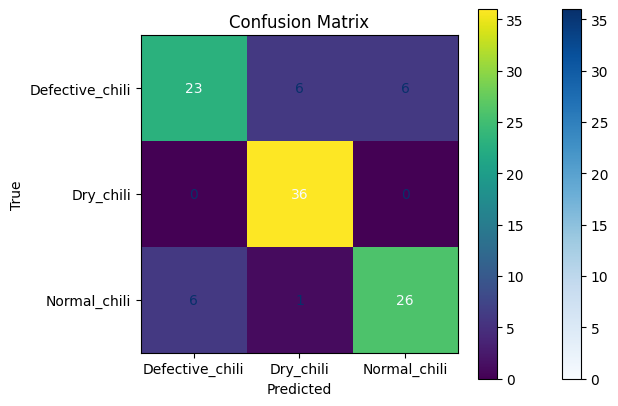

In [27]:


y_true = np.concatenate([y for _, y in val_ds])
y_pred = np.argmax(model.predict(val_ds), axis=1)

cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues")


plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()


In [23]:
from functools import partial
import tensorflow as tf

DefaultConv2D = partial(
    tf.keras.layers.Conv2D,
    kernel_size=3,
    padding="same",
    kernel_initializer="he_normal",
    use_bias=False
)

custom_model = tf.keras.Sequential([

    # ===== Block 1 =====
    DefaultConv2D(32, input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    

    # ===== Block 2 =====
    DefaultConv2D(64),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    

    # ===== Block 3 =====
    DefaultConv2D(128),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    

    # ===== Block 4 =====
    DefaultConv2D(256),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(num_classes, activation="softmax")
])

custom_model.summary()

custom_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=4,
        min_lr=1e-6
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_custom_cnn.h5",
        monitor="val_loss",
        save_best_only=True
    )
]


history = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

custom_model.save("custom_cnn_final.h5")
print("✅ Model saved")


c:\Users\Thanh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_119 (Conv2D)             │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_120 (Conv2D)             │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_121 (Conv2D)             │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_122 (Conv2D)             │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,812,899 (25.99 MB)

 Trainable params: 6,811,939 (25.99 MB)

...

148/148 ━━━━━━━━━━━━━━━━━━━━ 119s 780ms/step - accuracy: 0.5110 - loss: 3.4261 - val_accuracy: 0.4135 - val_loss: 1.0582 - learning_rate: 0.0010
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 105s 709ms/step - accuracy: 0.5572 - loss: 0.9371 - val_accuracy: 0.3654 - val_loss: 1.0948 - learning_rate: 0.0010
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 96s 647ms/step - accuracy: 0.5364 - loss: 0.9118 - val_accuracy: 0.3365 - val_loss: 1.0930 - learning_rate: 0.0010
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 825ms/step - accuracy: 0.5125 - loss: 0.9119

148/148 ━━━━━━━━━━━━━━━━━━━━ 124s 838ms/step - accuracy: 0.5314 - loss: 0.9218 - val_accuracy: 0.4423 - val_loss: 1.0548 - learning_rate: 0.0010
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 737ms/step - accuracy: 0.5458 - loss: 0.9078

148/148 ━━━━━━━━━━━━━━━━━━━━ 111s 747ms/step - accuracy: 0.5352 - loss: 0.9036 - val_accuracy: 0.4038 - val_loss: 1.0283 - learning_rate: 0.0010
Epoch 6/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 139s 941ms/step - accuracy: 0.6034 - loss: 0.8364 - val_accuracy: 0.4038 - val_loss: 1.1101 - learning_rate: 0.0010
Epoch 7/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 128s 865ms/step - accuracy: 0.6258 - loss: 0.8293 - val_accuracy: 0.4038 - val_loss: 1.0294 - learning_rate: 0.0010
Epoch 8/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 117s 695ms/step - accuracy: 0.6534 - loss: 0.7741 - val_accuracy: 0.3846 - val_loss: 1.0355 - learning_rate: 0.0010
Epoch 9/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 105s 709ms/step - accuracy: 0.6203 - loss: 0.8115 - val_accuracy: 0.3846 - val_loss: 1.0940 - learning_rate: 0.0010
Epoch 10/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - accuracy: 0.6341 - loss: 0.7617

148/148 ━━━━━━━━━━━━━━━━━━━━ 101s 683ms/step - accuracy: 0.6542 - loss: 0.7482 - val_accuracy: 0.4038 - val_loss: 1.0249 - learning_rate: 3.0000e-04
Epoch 11/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 97s 654ms/step - accuracy: 0.6585 - loss: 0.7332 - val_accuracy: 0.3942 - val_loss: 1.1005 - learning_rate: 3.0000e-04
Epoch 12/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 97s 654ms/step - accuracy: 0.6725 - loss: 0.7248 - val_accuracy: 0.3942 - val_loss: 1.0443 - learning_rate: 3.0000e-04
Epoch 13/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 98s 659ms/step - accuracy: 0.6831 - loss: 0.7025 - val_accuracy: 0.3846 - val_loss: 1.1954 - learning_rate: 3.0000e-04
Epoch 14/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 96s 651ms/step - accuracy: 0.6826 - loss: 0.7037 - val_accuracy: 0.3942 - val_loss: 1.2234 - learning_rate: 3.0000e-04
Epoch 15/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 97s 656ms/step - accuracy: 0.6898 - loss: 0.6940 - val_accuracy: 0.4135 - val_loss: 1.2324 - learning_rate: 9.0000e-05
Epoch 16/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 96s 651ms/

✅ Model saved


In [24]:
# ================== IN METRICS ==================
evaluate_dataset(custom_model, train_ds, class_names, "TRAIN")
evaluate_dataset(custom_model, val_ds, class_names, "VALIDATION")


📊 TRAIN METRICS
Accuracy : 0.6674
Precision: 0.8303
Recall   : 0.5673
F1-score : 0.5041

📋 TRAIN CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Defective_chili       1.00      0.01      0.02       464
      Dry_chili       0.97      0.69      0.81      1060
   Normal_chili       0.52      1.00      0.69       836

       accuracy                           0.67      2360
      macro avg       0.83      0.57      0.50      2360
   weighted avg       0.82      0.67      0.61      2360


📊 VALIDATION METRICS
Accuracy : 0.4038
Precision: 0.4491
Recall   : 0.4167
F1-score : 0.3052

📋 VALIDATION CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Defective_chili       0.00      0.00      0.00        35
      Dry_chili       1.00      0.25      0.40        36
   Normal_chili       0.35      1.00      0.52        33

       accuracy                           0.40       104
      macro avg       0.45      0.42      0.31       104
   w

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step


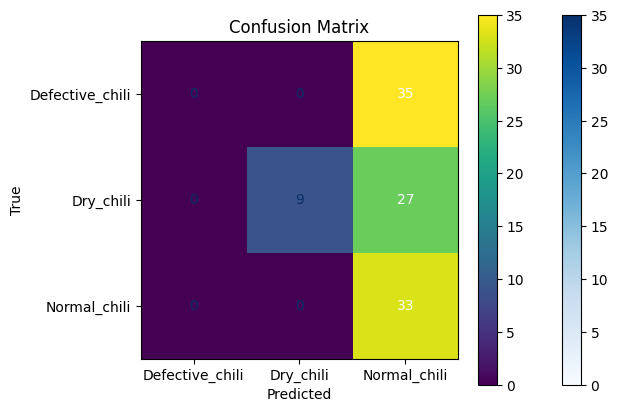

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

y_true = np.concatenate([y for _, y in val_ds])
y_pred = np.argmax(custom_model.predict(val_ds), axis=1)

cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues")


plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()
